In [10]:
import numpy as np

p1 = 0.2
p2 = 0.5
p3 = 0.8
n = 10_000

np.random.seed(42)
U = np.random.uniform(0, 1, n)

X1 = np.floor(np.log(U)/np.log(1-p1))+1
X2 = np.floor(np.log(U)/np.log(1-p2))+1
X3 = np.floor(np.log(U)/np.log(1-p3))+1

k1 = np.arange(1, int(X1.max()) + 1)
pmf1 = (1 - p1)**(k1 - 1) * p1

k2 = np.arange(1, int(X2.max()) + 1)
pmf2 = (1 - p2)**(k2 - 1) * p2


k3 = np.arange(1, int(X3.max()) + 1)
pmf3 = (1 - p3)**(k3 - 1) * p3


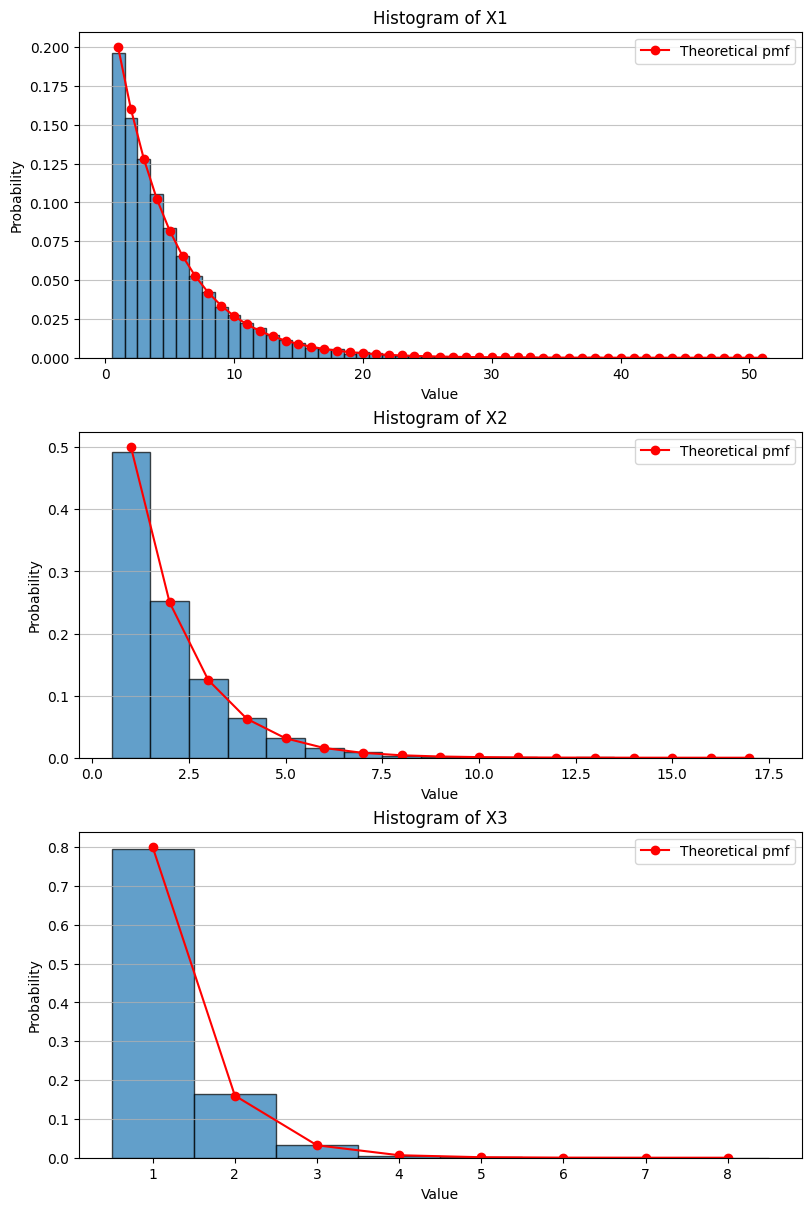

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 12), constrained_layout=True)

bins1 = np.arange(0.5, X1.max() + 1.5, 1)
bins2 = np.arange(0.5, X2.max() + 1.5, 1)
bins3 = np.arange(0.5, X3.max() + 1.5, 1)

axes[0].hist(X1, bins=bins1, density=True, edgecolor='black', alpha=0.7)

axes[0].plot(k1, pmf1, 'ro-', label='Theoretical pmf')
axes[0].set(title='Histogram of X1', xlabel='Value', ylabel='Probability')
axes[0].legend()

axes[1].hist(X2, bins=bins2, density=True, edgecolor='black', alpha=0.7)

axes[1].plot(k2, pmf2, 'ro-', label='Theoretical pmf')
axes[1].set(title='Histogram of X2', xlabel='Value', ylabel='Probability')
axes[1].legend()

axes[2].hist(X3, bins=bins3, density=True, edgecolor='black', alpha=0.7)

axes[2].plot(k3, pmf3, 'ro-', label='Theoretical pmf')
axes[2].set(title='Histogram of X3', xlabel='Value', ylabel='Probability')
axes[2].legend()

for ax in axes:
    ax.grid(axis='y', alpha=0.75)

plt.show()

# Part 2

## Direct method

In [65]:
p1 = 7/48
p2 = 5/48
p3 = 1/8
p4 = 1/16
p5 = 1/4
p6 = 5/16

p_i = np.array([p1, p2, p3, p4, p5, p6])
P = np.cumsum(p_i)

np.random.seed(42)
rand_n = np.random.uniform(0, 1, 1)

def check_interval(rand_n, P):
    for i in range(len(P)):
        lower_bound = 0 if i == 0 else P[i-1]
        if lower_bound < rand_n <= P[i]:            
            return i+1

result = check_interval(rand_n, P)

def check_interval_scale(U, P):
    return np.searchsorted(P, U) + 1

rand_n_many = np.random.uniform(0, 1, 10_000)
results = check_interval_scale(rand_n_many, P)



## Rejection

In [66]:
# Baseline

q = [1/6, 1/6, 1/6, 1/6, 1/6, 1/6]
p_i = np.array([p1, p2, p3, p4, p5, p6])

c = np.max(p_i/q)

"""
def accept_reject(U, c, p_i, q):
    U = np.random.uniform(0, 1, 2)
    I = int(np.floor(6*U[0])+1)
    if U[1] <= p_i[I-1]/(c*q[I-1]):
        return I
    else:        
        return accept_reject(c, p_i, q)
    

def accept_reject_many(c, p_i, q, n):
    results = []
    for _ in range(n):
        results.append(accept_reject(c, p_i, q))
    return np.array(results)

"""

'\ndef accept_reject(U, c, p_i, q):\n    U = np.random.uniform(0, 1, 2)\n    I = int(np.floor(6*U[0])+1)\n    if U[1] <= p_i[I-1]/(c*q[I-1]):\n        return I\n    else:        \n        return accept_reject(c, p_i, q)\n    \n\ndef accept_reject_many(c, p_i, q, n):\n    results = []\n    for _ in range(n):\n        results.append(accept_reject(c, p_i, q))\n    return np.array(results)\n\n'

In [67]:
def accept_reject(U, c, p_i, q):
    I = int(np.floor(6 * U[0]) + 1)
    if U[1] <= p_i[I - 1] / (c * q[I - 1]):
        return I
    else:        
        U_retry = np.random.uniform(0, 1, 2)
        return accept_reject(U_retry, c, p_i, q)

def accept_reject_many(c, p_i, q, n):
    results = []
    for _ in range(n):
        U_initial = np.random.uniform(0, 1, 2)
        results.append(accept_reject(U_initial, c, p_i, q))
    return np.array(results)

# Alias method

In [68]:
def preprocess_alias(p):
    k = len(p_i)
    p_alias = k*p_i

    alias_table = np.zeros(k)
    prob_table = np.zeros(k)

    small = []
    large = []

    for i in range(k):
        if p_alias[i] < 1:
            small.append(i)
        else:
            large.append(i)
    
    while small and large:
        small_idx = small.pop()
        large_idx = large.pop()

        prob_table[small_idx] = p_alias[small_idx]
        alias_table[small_idx] = large_idx

        p_alias[large_idx] = (p_alias[large_idx] + p_alias[small_idx]) - 1

        if p_alias[large_idx] < 1:
            small.append(large_idx)
        else:
            large.append(large_idx)
        
    while large:
        large_idx = large.pop()
        prob_table[large_idx] = 1
        alias_table[large_idx] = -1
    
    while small:
        small_idx = small.pop()
        prob_table[small_idx] = 1
        alias_table[small_idx] = -1
    
    return prob_table, alias_table


In [69]:
prob_table, alias_table = preprocess_alias(p_i)

prob_table, alias_table

(array([0.875, 0.625, 0.75 , 0.375, 1.   , 0.625]),
 array([ 4.,  5.,  5.,  5., -1.,  4.]))

In [72]:
def alias_method(U, prob_table, alias_table):
    Un = U*6
    I = np.floor(Un).astype(int)
    V = Un-I
    samples = np.where(V <= prob_table[I], I+1, alias_table[I]+1)
    return samples

U = np.random.uniform(0,1,10_000)
alias_method(U, prob_table, alias_table)

array([2., 3., 6., ..., 3., 2., 6.], shape=(10000,))

# Part 3

In [ ]:
# Compare the three methods
import time

n_simulations = 10_000
np.random.seed(42)
U_shared = np.random.uniform(0, 1, n_simulations)

# Time Method 1: Direct Method
start = time.time()
results_direct = check_interval_scale(U_shared, P)
time_direct = time.time() - start

# Time Method 2: Rejection Method
start = time.time()
results_rejection = accept_reject_many(c, p_i, q, n_simulations)
time_rejection = time.time() - start

# Time Method 3: Alias Method
start = time.time()
prob_table, alias_table = preprocess_alias(p_i)
results_alias = alias_method(U_shared, prob_table, alias_table).astype(int)
time_alias = time.time() - start

print(f"Direct Method Time:    {time_direct:.5f} seconds")
print(f"Rejection Method Time: {time_rejection:.5f} seconds")
print(f"Alias Method Time:     {time_alias:.5f} seconds")

Direct Method Time:    0.00084 seconds
Rejection Method Time: 0.04334 seconds
Alias Method Time:     0.00261 seconds


In [81]:

print("Target Probabilities: ", p_i)
print("Direct Proportions:   ", np.bincount(results_direct)[1:] / n_simulations)
print("Rejection Proportions:", np.bincount(results_rejection)[1:] / n_simulations)
print("Alias Proportions:    ", np.bincount(results_alias)[1:] / n_simulations)

Target Probabilities:  [0.14583333 0.10416667 0.125      0.0625     0.25       0.3125    ]
Direct Proportions:    [0.1499 0.1048 0.1255 0.0649 0.2527 0.3022]
Rejection Proportions: [0.1425 0.1089 0.1241 0.0633 0.25   0.3112]
Alias Proportions:     [0.1499 0.1062 0.1295 0.0648 0.2455 0.3041]


# Ex3

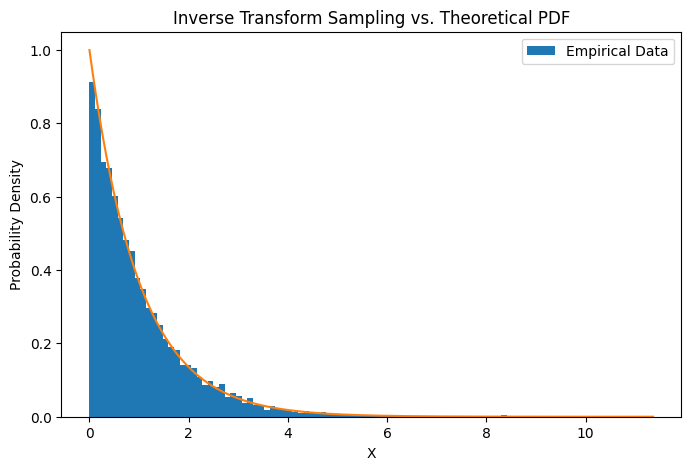

In [107]:
np.random.seed(42)
size = 10_000
lambda_ = 1

U = np.random.uniform(0, 1, size)
X_exp = -np.log(U) / lambda_

x_axis = np.linspace(0, np.max(X_exp), 1000)
theoretical_pdf = lambda_ * np.exp(-lambda_ * x_axis)

plt.figure(figsize=(8, 5))
plt.hist(X_exp, bins=100, density=True, label='Empirical Data')
plt.plot(x_axis, theoretical_pdf)

plt.title("Inverse Transform Sampling vs. Theoretical PDF")
plt.xlabel("X")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


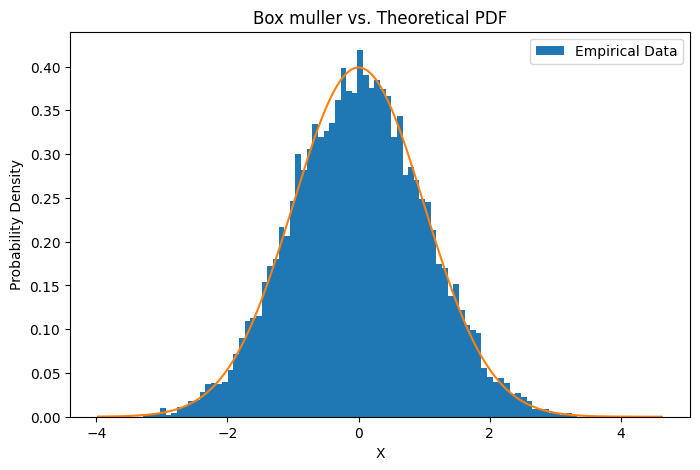

In [116]:
np.random.seed(42)
size = 10_000
lambda_ = 1

U1 = np.random.uniform(0, 1, size)
U2 = np.random.uniform(0,1,size)
X_norm = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)

x_axis = np.linspace(np.min(X_norm), np.max(X_norm), 10000)
theoretical_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_axis**2)

plt.figure(figsize=(8, 5))
plt.hist(X_norm, bins=100, density=True, label='Empirical Data')
plt.plot(x_axis, theoretical_pdf)

plt.title("Box muller vs. Theoretical PDF")
plt.xlabel("X")
plt.ylabel("Probability Density")
plt.legend()
plt.show()


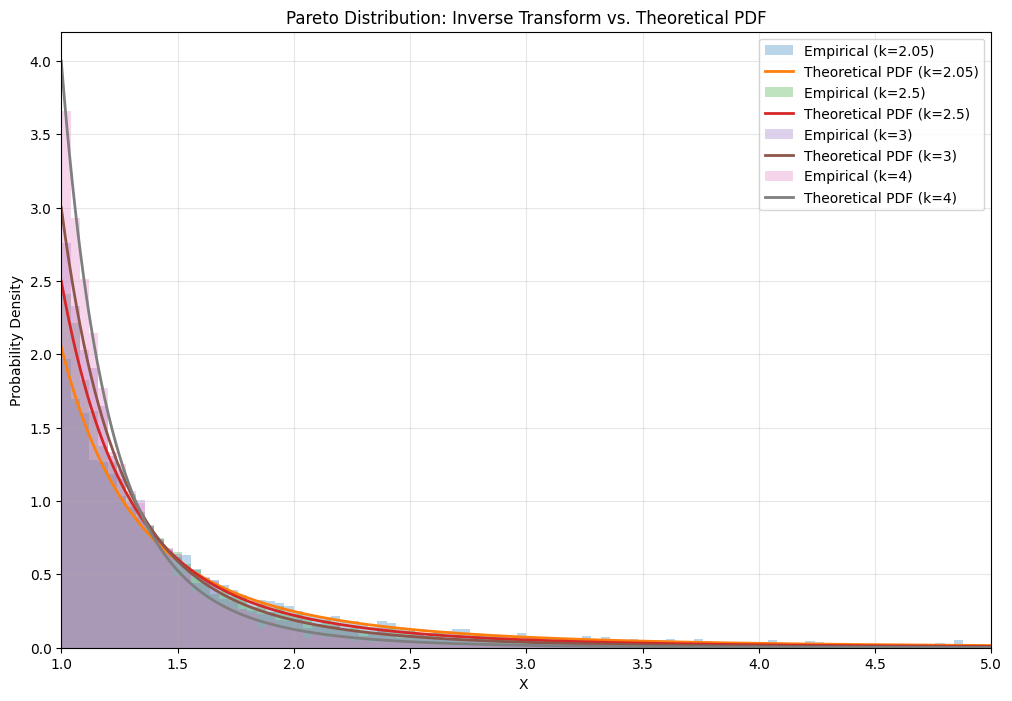

In [138]:
np.random.seed(42)
size = 10_000
beta = 1 
k_values = [2.05, 2.5, 3, 4]

# Set up the plot
plt.figure(figsize=(12, 8))

X_par = []

for k in k_values:
    U = np.random.uniform(0, 1, size)
    X_pa = beta * (U ** (-1 / k))
    X_par.append(X_pa)
    
    x_axis = np.linspace(beta, 5, 1000)
    
    theoretical_pdf = (k * (beta**k)) / (x_axis**(k + 1))
    
    plt.hist(X_pa, bins=100, range=(beta, 5), density=True, alpha=0.3, label=f'Empirical (k={k})')
    
    plt.plot(x_axis, theoretical_pdf, lw=2, label=f'Theoretical PDF (k={k})')

plt.title("Pareto Distribution: Inverse Transform vs. Theoretical PDF")
plt.xlabel("X ")
plt.ylabel("Probability Density")
plt.xlim(beta, 5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [139]:
import pandas as pd


beta = 1
E_theoretical = []
V_theoretical = []
X_mean = []
X_var = []
for i in range(len(k_values)):
    E_theoretical.append(beta*k_values[i]/(k_values[i]-1))
    V_theoretical.append(beta**2*k_values[i]/((k_values[i]-1)**2*(k_values[i]-2)))
    X_mean.append(np.mean(X_par[i]))
    X_var.append(np.var(X_par[i]))

df = pd.DataFrame({
    'k': k_values,
    'Theoretical Mean': E_theoretical,
    'Empirical Mean': X_mean,
    'Theoretical Var': V_theoretical,
    'Empirical Var': X_var
})

df

,k,Theoretical Mean,Empirical Mean,Theoretical Var,Empirical Var
0,2.05,1.952381,1.999874,37.188209,15.481378
1,2.50,1.666667,1.651634,2.222222,1.419199
2,3.00,1.500000,1.494529,0.750000,0.715552
3,4.00,1.333333,1.337367,0.222222,0.256733


In [149]:
import scipy.stats as stats

n_obs = 10
n = 100

np.random.seed(42)

U1_ci = np.random.rand(n, n_obs)
U2_ci = np.random.rand(n, n_obs)

X_norm_ci = np.sqrt(-2 * np.log(U1_ci)) * np.cos(2 * np.pi * U2_ci)


means_ = np.mean(X_norm_ci, axis = 1)
vars_ = np.var(X_norm_ci, axis = 1, ddof = 1)

t_crit = stats.t.ppf(0.975, df = n_obs-1)
mean_margin = t_crit * np.sqrt(vars_ / n_obs)
mean_lower = means_ - mean_margin
mean_upper = means_ + mean_margin

mean_cover = np.sum((mean_lower <= 0) & (mean_upper >= 0))

chi2_lower = stats.chi2.ppf(0.025, df = n_obs-1)
chi2_upper = stats.chi2.ppf(0.975, df = n_obs -1)

var_lower = (n_obs - 1) * vars_ / chi2_upper
var_upper = (n_obs - 1) * vars_ / chi2_lower

var_cover = np.sum((var_lower <= 1) & (var_upper >= 1))

print(f"Mean CIs containing true mean (0):     {mean_cover} / 100")
print(f"Variance CIs containing true var (1):  {var_cover} / 100")


Mean CIs containing true mean (0):     99 / 100
Variance CIs containing true var (1):  98 / 100


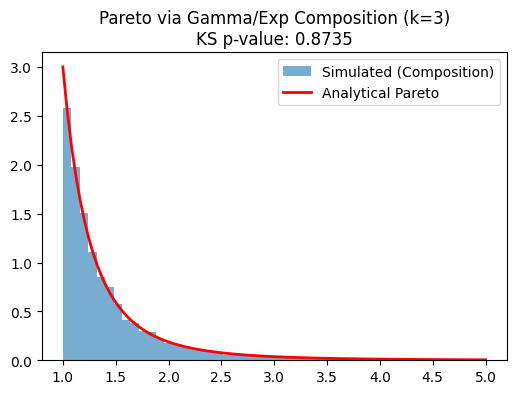

In [151]:
np.random.seed(42)
n = 10_000
lambda_ = 1
k = 3
U1 = np.random.uniform(0,1,10_000)
U2 = np.random.uniform(0,1,10_000)
U3 = np.random.uniform(0,1,10_000)


Y = -(1/lambda_) * np.log(U1*U2*U3)

U4 = np.random.rand(n)
X_cond = -(1.0 / Y) * np.log(U4)

X_comp = X_cond + lambda_

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(X_comp, bins=50, range=(1, 5), density=True, alpha=0.6, label="Simulated (Composition)")

x_c = np.linspace(1, 5, 100)
ax.plot(x_c, stats.pareto.pdf(x_c, b=k, scale=lambda_), 'r-', lw=2, label="Analytical Pareto")

ks_comp = stats.kstest(X_comp, lambda x: stats.pareto.cdf(x, b=k, scale=lambda_))
ax.set_title(f"Pareto via Gamma/Exp Composition (k=3)\nKS p-value: {ks_comp.pvalue:.4f}")
ax.legend()
plt.show()